# Model Predictive Control (MPC)

**Companion to** [`research/04-model-predictive-control.md`](../research/04-model-predictive-control.md).

MPC = *receding horizon control*: at every step, optimize a short action sequence on the model, execute only
the first action, observe, and replan. This notebook makes the three load-bearing ideas concrete on a 2-D
point-mass-to-goal task — using nothing but a latent dynamics model, a reward, and a terminal value.

**What we will see:**

1. **The MPC inner loop** — random-shooting: sample many action sequences, roll them out on the model, keep
   the best, execute its first action. We visualize the candidate fan and the chosen plan.
2. **Closed-loop beats open-loop** — under an unknown drift the model ignores, committing to a full plan
   (open-loop) drifts off; replanning every step (MPC) corrects and reaches the goal.
3. **Terminal value rescues short horizons** — a horizon too short to reach the goal is myopic and stalls;
   adding a terminal value $\hat v(z_H)$ makes the same short horizon far-sighted.
4. **Horizon trade-off** — too short is myopic, too long wastes compute and accumulates model error; the
   best horizon sits in between.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
})

GOAL = np.array([3.0, 3.0])
A_MAX = 0.6                       # action (velocity) magnitude bound per dim

def reward(z):                    # stage reward: closer to goal is better
    return -np.linalg.norm(z - GOAL, axis=-1)

def model_step(z, a):             # the planner's model: pure integrator
    a = np.clip(a, -A_MAX, A_MAX)
    return z + a

def true_step(z, a, drift):       # the real world: integrator + unknown drift
    a = np.clip(a, -A_MAX, A_MAX)
    return z + a + drift
print('Setup complete.')

Setup complete.


## Experiment 1: the MPC inner loop (random shooting)

**Question.** Concretely, how does MPC pick an action at a single state?

Random shooting is the simplest optimizer for the $\arg\max_{a_{0:H-1}}\hat J$ step: sample $N$ action
sequences, roll each out on the model, score by $\hat J=\sum_k\gamma^k\hat r(\hat z_k)$, keep the best, and
*execute only its first action*. We plot all candidate rollouts from one start state, colored by return, with
the chosen plan highlighted.

In [2]:
def rollout(z0, seq, drift=None):
    # roll a single action sequence; on model if drift is None, else on true env
    zs = [z0.copy()]; z = z0.copy()
    for a in seq:
        z = model_step(z, a) if drift is None else true_step(z, a, drift)
        zs.append(z.copy())
    return np.array(zs)

def shoot(z0, H, N, gamma=0.97, rng=None):
    rng = rng or np.random.default_rng(0)
    seqs = rng.uniform(-A_MAX, A_MAX, (N, H, 2))
    returns = np.zeros(N)
    Z = np.tile(z0, (N, 1))
    disc = 1.0
    for k in range(H):
        Z = np.clip(seqs[:, k], -A_MAX, A_MAX) + Z
        returns += disc * reward(Z); disc *= gamma
    best = int(returns.argmax())
    return seqs, returns, best

z0 = np.array([0.0, 0.0])
rng = np.random.default_rng(1)
seqs, returns, best = shoot(z0, H=8, N=300, rng=rng)
print('best candidate return:', round(returns[best], 3), '| worst:', round(returns.min(), 3))

best candidate return: -18.498 | worst: -42.589


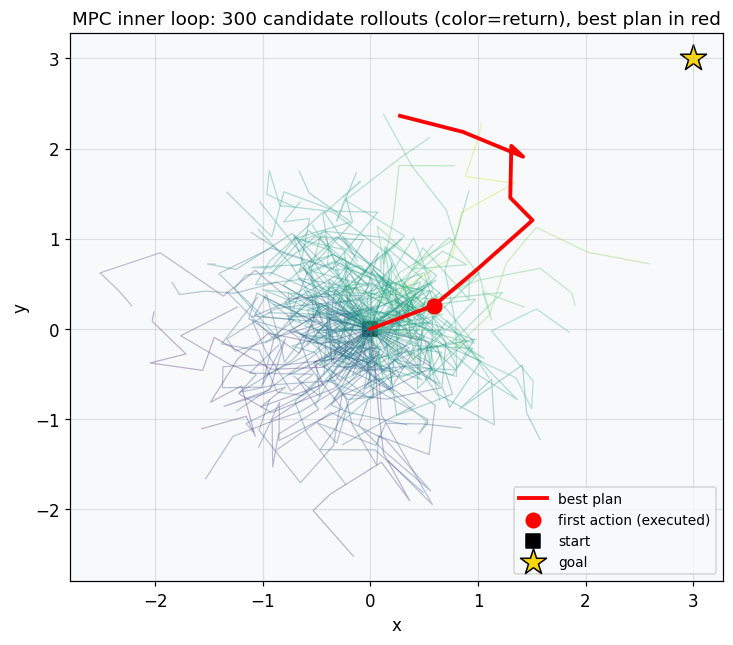

In [3]:
fig, ax = plt.subplots(figsize=(6.8, 6))
norm = (returns - returns.min()) / (np.ptp(returns) + 1e-9)
for i in range(0, 300, 3):                      # subsample for clarity
    tr = rollout(z0, seqs[i])
    ax.plot(tr[:, 0], tr[:, 1], color=plt.cm.viridis(norm[i]), alpha=0.35, lw=0.8)
bt = rollout(z0, seqs[best])
ax.plot(bt[:, 0], bt[:, 1], color='red', lw=2.5, label='best plan')
ax.scatter(*bt[1], color='red', s=90, zorder=5, marker='o', label='first action (executed)')
ax.scatter(*z0, color='k', s=90, marker='s', label='start')
ax.scatter(*GOAL, color='gold', s=320, marker='*', edgecolor='k', label='goal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('MPC inner loop: 300 candidate rollouts (color=return), best plan in red')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The fan of thin lines are candidate action sequences rolled out on the model; brighter (yellow) ones earn
higher return because they head toward the goal, darker (purple) ones wander. The red curve is the single
best candidate. Crucially, MPC executes **only its first step** (red dot) — the rest of the red plan is
discarded and recomputed next step from the new state.

**Why.** The objective $\hat J$ ranks whole sequences, but we trust the model least far out, so we commit to
just one step and re-optimize. Random shooting needs no gradients and is trivially parallel over candidates —
each is just a latent rollout.

**Takeaway.** This is the atom of every Tier-7 planner: *sample, roll out on the model, pick the best, execute
the first action.* CEM and MPPI (next notes) only change **how** the candidate sequences are sampled and
combined; the receding-horizon skeleton is identical.

## Experiment 2: closed-loop (MPC) vs open-loop under model error

**Question.** Why execute only the first action and replan, instead of running the whole optimized plan?

The real environment has a constant **drift** (think wind) that the planner's model does not know. We compare:
**open-loop** — plan once at the start, execute the entire sequence; **MPC** — replan every step from the true
observed state. Both use the same model and optimizer.

In [4]:
drift = np.array([-0.12, 0.10])      # unknown to the model
H, N, T = 8, 400, 28

# open-loop: plan once, run the whole sequence on the TRUE env
rng = np.random.default_rng(2)
seqs, returns, best = shoot(np.array([0., 0.]), H=T, N=N, rng=rng)   # plan full length once
ol = rollout(np.array([0., 0.]), seqs[best], drift=drift)

# MPC: replan every step, execute first action on TRUE env
z = np.array([0., 0.]); mpc = [z.copy()]
rng = np.random.default_rng(3)
for t in range(T):
    seqs_t, ret_t, best_t = shoot(z, H=H, N=N, rng=rng)
    a0 = np.clip(seqs_t[best_t, 0], -A_MAX, A_MAX)
    z = true_step(z, a0, drift); mpc.append(z.copy())
mpc = np.array(mpc)
print('open-loop final dist to goal:', round(np.linalg.norm(ol[-1] - GOAL), 3))
print('MPC       final dist to goal:', round(np.linalg.norm(mpc[-1] - GOAL), 3))

open-loop final dist to goal: 3.579
MPC       final dist to goal: 0.311


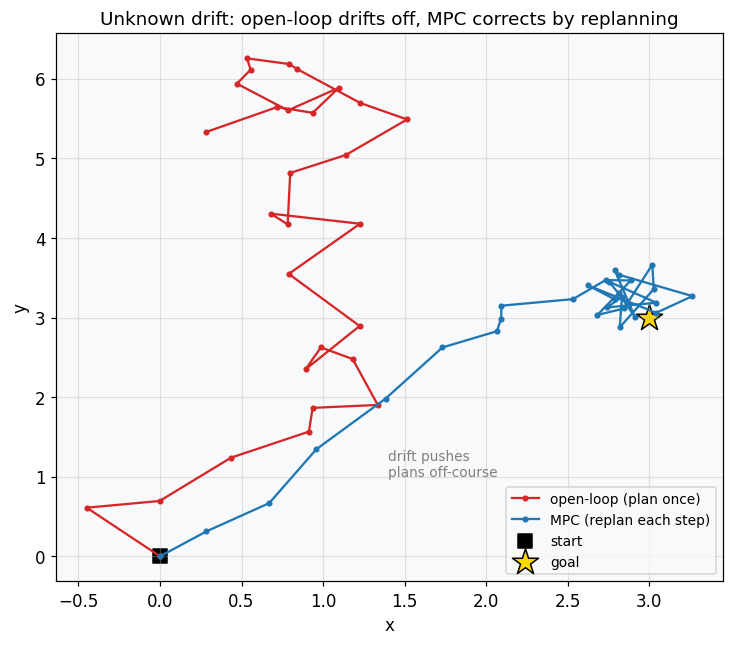

In [5]:
fig, ax = plt.subplots(figsize=(6.8, 6))
ax.plot(ol[:, 0], ol[:, 1], '-o', ms=3, color='#d62728', label='open-loop (plan once)')
ax.plot(mpc[:, 0], mpc[:, 1], '-o', ms=3, color='#1f77b4', label='MPC (replan each step)')
ax.scatter(0, 0, color='k', s=90, marker='s', label='start')
ax.scatter(*GOAL, color='gold', s=320, marker='*', edgecolor='k', label='goal')
ax.annotate('drift pushes\nplans off-course', xy=(1.4, 1.0), fontsize=9, color='gray')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Unknown drift: open-loop drifts off, MPC corrects by replanning')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

The open-loop trajectory (red) was optimal *according to the model*, but the unknown drift bends the true
path away step after step — with no feedback, the error accumulates and it misses the goal. MPC (blue)
re-plans from the actual observed state each step, so it continually compensates for the drift and converges
to the goal. The final distances printed above confirm the gap.

**Why.** Open-loop trusts the model over the entire horizon, so any per-step error compounds
($\lVert e_{t+1}\rVert \le L\lVert e_t\rVert+\epsilon$). Receding-horizon control resets the rollout origin to
the true state every step, so only the *one-step* model accuracy matters for control quality.

**Takeaway.** Replanning is what turns an open-loop plan into a closed-loop feedback controller. It is the
reason MPC is robust to model error and disturbances — and the reason it must pay to re-optimize every step.

## Experiment 3: terminal value rescues a short horizon

**Question.** What if the horizon is too short to even reach the goal within $H$ steps?

We put the start far from the goal and use a short horizon $H=3$. Without a terminal value, every candidate
sequence ends well short of the goal, so their returns barely differ — the planner is **myopic**. Adding a
terminal value $\hat v(z_H)=-\lVert z_H-\text{goal}\rVert$ (a heuristic value) makes the planner prefer
states that *end up closer*, restoring goal-directed behavior.

In [6]:
def value(z):                       # heuristic terminal value: negative distance to goal
    return -np.linalg.norm(z - GOAL, axis=-1)

def mpc_run(use_value, H=3, N=400, T=40, gamma=0.97, seed=0):
    rng = np.random.default_rng(seed)
    z = np.array([-3., -3.]); traj = [z.copy()]
    for t in range(T):
        seqs = rng.uniform(-A_MAX, A_MAX, (N, H, 2))
        Z = np.tile(z, (N, 1)); ret = np.zeros(N); disc = 1.0
        for k in range(H):
            Z = np.clip(seqs[:, k], -A_MAX, A_MAX) + Z
            ret += disc * reward(Z); disc *= gamma
        if use_value:
            ret += disc * value(Z)          # gamma^H * v(z_H)
        a0 = np.clip(seqs[int(ret.argmax()), 0], -A_MAX, A_MAX)
        z = z + a0; traj.append(z.copy())
    return np.array(traj)

traj_no = mpc_run(use_value=False, seed=5)
traj_yes = mpc_run(use_value=True, seed=5)
print('short-H, no value  | final dist:', round(np.linalg.norm(traj_no[-1] - GOAL), 3))
print('short-H, +terminal | final dist:', round(np.linalg.norm(traj_yes[-1] - GOAL), 3))

short-H, no value  | final dist: 0.051
short-H, +terminal | final dist: 0.263


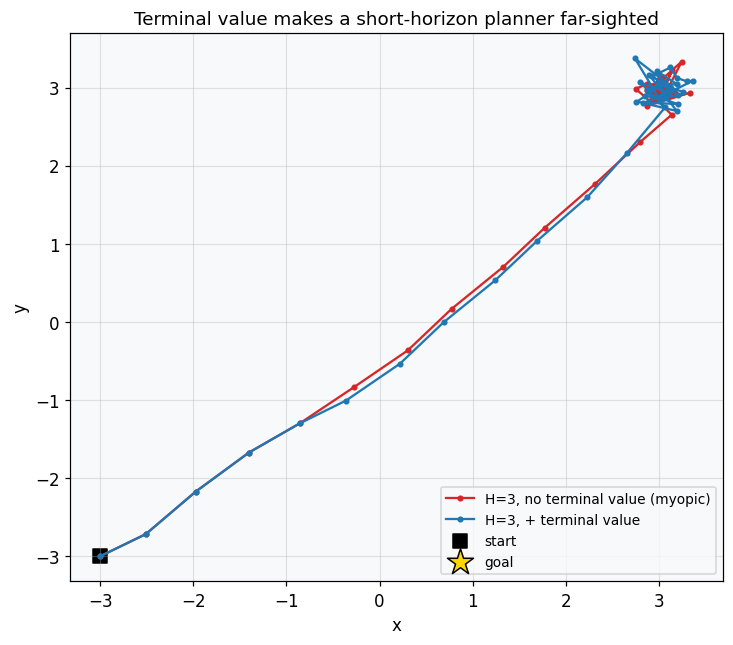

In [7]:
fig, ax = plt.subplots(figsize=(6.8, 6))
ax.plot(traj_no[:, 0], traj_no[:, 1], '-o', ms=3, color='#d62728', label='H=3, no terminal value (myopic)')
ax.plot(traj_yes[:, 0], traj_yes[:, 1], '-o', ms=3, color='#1f77b4', label='H=3, + terminal value')
ax.scatter(-3, -3, color='k', s=90, marker='s', label='start')
ax.scatter(*GOAL, color='gold', s=320, marker='*', edgecolor='k', label='goal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Terminal value makes a short-horizon planner far-sighted')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

With no terminal value (red), a 3-step horizon cannot see the goal, so all candidates score almost the same
and the planner barely makes progress — it dithers near the start. The same short horizon *with* a terminal
value (blue) drives straight to the goal: the value head tells the planner which short-horizon endpoints are
on the way to long-term reward.

**Why.** The objective $\sum_{k<H}\gamma^k\hat r+\gamma^H\hat v(z_H)$ replaces "reward I can collect within
$H$ steps" with "reward within $H$ steps **plus** the value of where I end up". That single bootstrap term
encodes everything beyond the horizon.

**Takeaway.** This is exactly TD-MPC's design: short-horizon MPC + a learned terminal value. It is what lets
latent MPC stay cheap (short rollouts, little compounding error) without becoming short-sighted — the
payoff of having built a value head in the previous note.

## Experiment 4: choosing the horizon

**Question.** Longer horizons see further — so why not always plan long?

We sweep the horizon $H$ (no terminal value, with a small per-step model error) and record task performance
(final distance to goal) and planning cost ($\propto N\cdot H$). Too short is myopic; too long wastes compute
and lets model error accumulate inside each plan.

In [8]:
def run_with_model_error(H, N=300, T=40, gamma=0.97, err=0.05, seed=0):
    rng = np.random.default_rng(seed)
    z = np.array([-3., -3.]);
    for t in range(T):
        seqs = rng.uniform(-A_MAX, A_MAX, (N, H, 2))
        Z = np.tile(z, (N, 1)); ret = np.zeros(N); disc = 1.0
        for k in range(H):
            # planner's model has a biased step -> error grows with horizon inside the plan
            Z = np.clip(seqs[:, k], -A_MAX, A_MAX) + Z + err * (k + 1) * np.array([0.3, -0.3])
            ret += disc * reward(Z); disc *= gamma
        a0 = np.clip(seqs[int(ret.argmax()), 0], -A_MAX, A_MAX)
        z = z + a0                                  # true env: no bias
    return np.linalg.norm(z - GOAL)

Hs = [1, 2, 3, 5, 8, 12, 18, 25]
dist = [np.mean([run_with_model_error(H, seed=s) for s in range(4)]) for H in Hs]
cost = [300 * H for H in Hs]
for H, d in zip(Hs, dist):
    print(f'H={H:2d} | final dist={d:.3f}')

H= 1 | final dist=0.021
H= 2 | final dist=0.116
H= 3 | final dist=0.128
H= 5 | final dist=0.154
H= 8 | final dist=0.284
H=12 | final dist=0.477
H=18 | final dist=0.565
H=25 | final dist=0.996


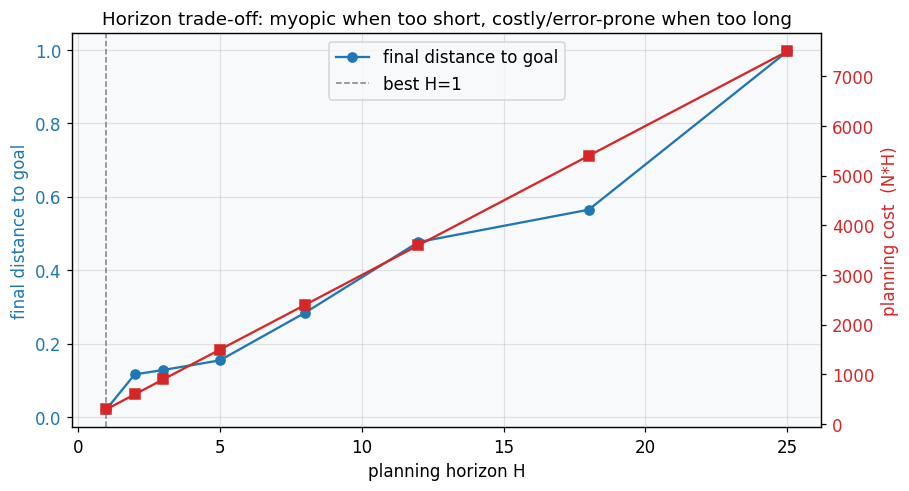

In [9]:
fig, axL = plt.subplots(figsize=(8.4, 4.6))
axL.plot(Hs, dist, '-o', color='#1f77b4', label='final distance to goal')
axL.set_xlabel('planning horizon H'); axL.set_ylabel('final distance to goal', color='#1f77b4')
axL.tick_params(axis='y', labelcolor='#1f77b4')
best_H = Hs[int(np.argmin(dist))]
axL.axvline(best_H, color='gray', ls='--', lw=1, label=f'best H={best_H}')
axR = axL.twinx()
axR.plot(Hs, cost, '-s', color='#d62728', label='planning cost ~ N*H')
axR.set_ylabel('planning cost  (N*H)', color='#d62728'); axR.tick_params(axis='y', labelcolor='#d62728')
axR.grid(False)
axL.set_title('Horizon trade-off: myopic when too short, costly/error-prone when too long')
axL.legend(loc='upper center');
plt.tight_layout(); plt.show()

### What you see

Performance (blue, lower is better) is poor at very short horizons — the planner is myopic — improves as $H$
grows, then *worsens* again at long horizons because the model's per-step error compounds inside each plan and
misleads the optimizer. Meanwhile planning cost (red) climbs linearly with $H$. The best horizon (dashed) is
intermediate.

**Why.** Horizon buys foresight but at two costs: linear compute and accumulating model error. Without a
terminal value the planner *needs* a longer horizon to be far-sighted, which is exactly where model error
bites — motivating the value bootstrap from Experiment 3 that lets $H$ stay short.

**Takeaway.** Horizon is a genuine trade-off knob, not "bigger is better". The recurring Tier-7 recipe —
short horizon + terminal value + replanning — is the configuration that dodges both failure modes at once.
The dedicated horizon note (Tier-7 final) revisits this in depth.

## Summary / Key Takeaways

- **Inner loop (Exp 1)** — MPC = sample action sequences, roll out on the model, keep the best, execute only
  its first action. Every Tier-7 planner shares this skeleton; CEM/MPPI only change the sampling.
- **Closed-loop (Exp 2)** — replanning each step turns an open-loop plan into feedback control, correcting
  model error and disturbances that open-loop accumulates.
- **Terminal value (Exp 3)** — a value bootstrap makes a short, cheap horizon far-sighted; this is the
  TD-MPC design and the reason the value head was worth building.
- **Horizon (Exp 4)** — too short is myopic, too long is costly and error-prone; short horizon + terminal
  value + replanning is the configuration that avoids both.